In [1]:
import polars as pl

# df = pl.read_csv('data/arxiv-metadata-oai-snapshot.json')

In [2]:
import json

data = []
with open('data/arxiv-metadata-oai-snapshot.json') as f:
    for line in f.readlines():
        data.append(json.loads(line))

In [3]:
df = pl.DataFrame(data)
df.head()

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
str,str,str,str,str,str,str,str,str,str,str,list[struct[2]],str,list[list[str]]
"""0704.0001""","""Pavel Nadolsky""","""C. Bal\'azs, E. L. Berger, P. …","""Calculation of prompt diphoton…","""37 pages, 15 figures; publishe…","""Phys.Rev.D76:013009,2007""","""10.1103/PhysRevD.76.013009""","""ANL-HEP-PR-07-12""","""hep-ph""",null,""" A fully differential calcula…","[{""v1"",""Mon, 2 Apr 2007 19:18:42 GMT""}, {""v2"",""Tue, 24 Jul 2007 20:10:27 GMT""}]","""2008-11-26""","[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]"
"""0704.0002""","""Louis Theran""","""Ileana Streinu and Louis Thera…","""Sparsity-certifying Graph Deco…","""To appear in Graphs and Combin…",null,null,null,"""math.CO cs.CG""","""http://arxiv.org/licenses/none…",""" We describe a new algorithm,…","[{""v1"",""Sat, 31 Mar 2007 02:26:18 GMT""}, {""v2"",""Sat, 13 Dec 2008 17:26:00 GMT""}]","""2008-12-13""","[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]"
"""0704.0003""","""Hongjun Pan""","""Hongjun Pan""","""The evolution of the Earth-Moo…","""23 pages, 3 figures""",null,null,null,"""physics.gen-ph""",null,""" The evolution of Earth-Moon …","[{""v1"",""Sun, 1 Apr 2007 20:46:54 GMT""}, {""v2"",""Sat, 8 Dec 2007 23:47:24 GMT""}, {""v3"",""Sun, 13 Jan 2008 00:36:28 GMT""}]","""2008-01-13""","[[""Pan"", ""Hongjun"", """"]]"
"""0704.0004""","""David Callan""","""David Callan""","""A determinant of Stirling cycl…","""11 pages""",null,null,null,"""math.CO""",null,""" We show that a determinant o…","[{""v1"",""Sat, 31 Mar 2007 03:16:14 GMT""}]","""2007-05-23""","[[""Callan"", ""David"", """"]]"
"""0704.0005""","""Alberto Torchinsky""","""Wael Abu-Shammala and Alberto …","""From dyadic $\Lambda_{\alpha}$…",null,"""Illinois J. Math. 52 (2008) no…",null,null,"""math.CA math.FA""",null,""" In this paper we show how to…","[{""v1"",""Mon, 2 Apr 2007 18:09:58 GMT""}]","""2013-10-15""","[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]"


In [4]:
df.describe()

statistic,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
str,str,str,str,str,str,str,str,str,str,str,str,f64,str,f64
"""count""","""2656318""","""2641129""","""2656318""","""2656318""","""1975730""","""878139""","""1222247""","""183808""","""2656318""","""2203522""","""2656318""",2.656318e6,"""2656318""",2.656318e6
"""null_count""","""0""","""15189""","""0""","""0""","""680588""","""1778179""","""1434071""","""2472510""","""0""","""452796""","""0""",0.0,"""0""",0.0
"""mean""",null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""","""0704.0001""","""""A. J."" Askew""","""""Andressa Gomes"""" and ""Mykael …","""!-Graphs with Trivial Overlap …","""!! pages 15 figures""",""""" Coding and Cryptography,"" Pr…","""0.1002/aisy.202300667""","""""Bipartite Quantum Interaction…","""acc-phys hep-ex physics.acc-ph""","""http://arxiv.org/licenses/none…",""" !-graphs provide a means of …",null,"""2007-05-23""",null
"""25%""",null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""","""supr-con/9609004""","""Øyvind Christiansen""","""Ozge Nilay Yalcin, Nouf Abukh…","""Weyl formula for the negativ…","""ï»¿This article has been remov…","""Épijournal de Géométrie Algébr…","""https://doi.org/10.25046/aj060…","""{UGVA-DPNC 1997/10-173 October…","""supr-con cond-mat.supr-con qua…","""http://creativecommons.org/pub…",""" A search for radiative deca…",null,"""2025-01-31""",null


In [5]:
def filter_whitespace_vals(names_list):
    print(type(names_list), names_list, len(names_list))
    for i in range(len(names_list)):
        print(names_list[i])
        names_list[i] = list(filter(lambda val: val != "", names_list[i]))
    print(type(names_list), names_list)
    return names_list

version_parsed_df = df.with_columns(
    latest_version_number=pl.col('versions').list.last().struct.field("version").str.slice(1).cast(pl.Int32),
    latest_version_date=pl.col('versions').list.last().struct.field('created').str.to_date("%a, %d %b %Y %H:%M:%S %Z"),
    authors_list=pl.col('authors_parsed'),  # .list.eval(pl.element().list.join(' ')),
)
version_parsed_df

id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,latest_version_number,latest_version_date,authors_list
str,str,str,str,str,str,str,str,str,str,str,list[struct[2]],str,list[list[str]],i32,date,list[list[str]]
"""0704.0001""","""Pavel Nadolsky""","""C. Bal\'azs, E. L. Berger, P. …","""Calculation of prompt diphoton…","""37 pages, 15 figures; publishe…","""Phys.Rev.D76:013009,2007""","""10.1103/PhysRevD.76.013009""","""ANL-HEP-PR-07-12""","""hep-ph""",null,""" A fully differential calcula…","[{""v1"",""Mon, 2 Apr 2007 19:18:42 GMT""}, {""v2"",""Tue, 24 Jul 2007 20:10:27 GMT""}]","""2008-11-26""","[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]",2,2007-07-24,"[[""Balázs"", ""C."", """"], [""Berger"", ""E. L."", """"], … [""Yuan"", ""C. -P."", """"]]"
"""0704.0002""","""Louis Theran""","""Ileana Streinu and Louis Thera…","""Sparsity-certifying Graph Deco…","""To appear in Graphs and Combin…",null,null,null,"""math.CO cs.CG""","""http://arxiv.org/licenses/none…",""" We describe a new algorithm,…","[{""v1"",""Sat, 31 Mar 2007 02:26:18 GMT""}, {""v2"",""Sat, 13 Dec 2008 17:26:00 GMT""}]","""2008-12-13""","[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]",2,2008-12-13,"[[""Streinu"", ""Ileana"", """"], [""Theran"", ""Louis"", """"]]"
"""0704.0003""","""Hongjun Pan""","""Hongjun Pan""","""The evolution of the Earth-Moo…","""23 pages, 3 figures""",null,null,null,"""physics.gen-ph""",null,""" The evolution of Earth-Moon …","[{""v1"",""Sun, 1 Apr 2007 20:46:54 GMT""}, {""v2"",""Sat, 8 Dec 2007 23:47:24 GMT""}, {""v3"",""Sun, 13 Jan 2008 00:36:28 GMT""}]","""2008-01-13""","[[""Pan"", ""Hongjun"", """"]]",3,2008-01-13,"[[""Pan"", ""Hongjun"", """"]]"
"""0704.0004""","""David Callan""","""David Callan""","""A determinant of Stirling cycl…","""11 pages""",null,null,null,"""math.CO""",null,""" We show that a determinant o…","[{""v1"",""Sat, 31 Mar 2007 03:16:14 GMT""}]","""2007-05-23""","[[""Callan"", ""David"", """"]]",1,2007-03-31,"[[""Callan"", ""David"", """"]]"
"""0704.0005""","""Alberto Torchinsky""","""Wael Abu-Shammala and Alberto …","""From dyadic $\Lambda_{\alpha}$…",null,"""Illinois J. Math. 52 (2008) no…",null,null,"""math.CA math.FA""",null,""" In this paper we show how to…","[{""v1"",""Mon, 2 Apr 2007 18:09:58 GMT""}]","""2013-10-15""","[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]",1,2007-04-02,"[[""Abu-Shammala"", ""Wael"", """"], [""Torchinsky"", ""Alberto"", """"]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""supr-con/9608008""","""Ruslan Prozorov""","""R. Prozorov, M. Konczykowski, …","""On the origin of the irreversi…","""19 pages, LaTex, 6 PostScript …",null,"""10.1103/PhysRevB.54.15530""",null,"""supr-con cond-mat.supr-con""",null,""" We report on measurements of…","[{""v1"",""Mon, 26 Aug 1996 15:08:35 GMT""}]","""2009-10-30""","[[""Prozorov"", ""R."", """"], [""Konczykowski"", ""M."", """"], … [""Koren"", ""G."", """"]]",1,1996-08-26,"[[""Prozorov"", ""R."", """"], [""Konczykowski"", ""M."", """"], … [""Koren"", ""G."", """"]]"
"""supr-con/9609001""","""Durga P. Choudhury""","""Durga P. Choudhury, Balam A. W…","""Nonlinear Response of HTSC Thi…","""4 pages, LaTeX type, Uses IEEE…",null,"""10.1109/77.620744""",null,"""supr-con cond-mat.supr-con""",null,""" The non-linear microwave sur…","[{""v1"",""Sat, 31 Aug 1996 17:34:38 GMT""}]","""2016-11-18""","[[""Choudhury"", ""Durga P."", … ""Physics Department, Northeastern University and Rome Laboratory, Hanscom AFB.""], [""Willemsen"", ""Balam A."", … ""Physics Department, Northeastern University and Rome Laboratory, Hanscom AFB.""], … [""Sridhar"", ""S."", … ""Physics Department, Northeastern University and Rome Laboratory, Hanscom AFB.""]]",1,1996-08-31,"[[""Choudhury"", ""Durga P."", … ""Physics Department, Northeastern University and Rome Laboratory, Hanscom AFB.""], [""Willemsen"", ""Balam A."", … ""Physics Departmen

In [6]:
df.select('authors')[6].item()

'Alejandro Corichi, Tatjana Vukasinac and Jose A. Zapata'

mkdir -p failed for path /media/mark/eea9a987-97ec-485a-8db9-789b8cdc04c3/trueblocks_data/matplotlib: [Errno 13] Permission denied: '/media/mark/eea9a987-97ec-485a-8db9-789b8cdc04c3'
Matplotlib created a temporary cache directory at /tmp/matplotlib-qh3dwjbu because there was an issue with the default path (/media/mark/eea9a987-97ec-485a-8db9-789b8cdc04c3/trueblocks_data/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


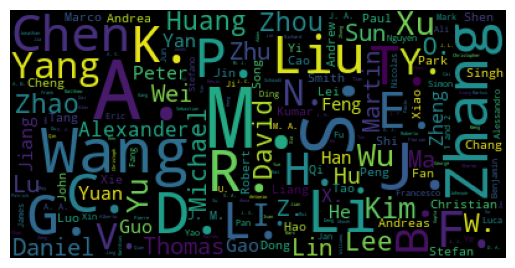

In [7]:
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt

author_words = version_parsed_df.select(pl.col('authors_parsed').list.explode().list.explode().alias('author_words'))
d = {word: times for word, times in author_words.group_by('author_words').len().rows()}
wc = WordCloud()
wc.fit_words(d)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [8]:
print(d.get('Univ.'))
print(d.get('Univ'))
sub_total = 0
total = 0
for k, v in d.items():
    total += v
    if k.lower().startswith('univ'):
        sub_total += v
        # print(k,v)
print(total, sub_total, sub_total/total * 100)

1
None
36960743 33013 0.08931909188080986


In [5]:
df.select(pl.col('update_date').max()).head()

update_date
str
"""2025-01-31"""


In [6]:
update_dist = df.group_by(pl.col('update_date')).len()
update_dist.head()

update_date,len
str,u32
"""2016-04-29""",270
"""2012-03-15""",191
"""2020-09-08""",846
"""2022-10-03""",533
"""2008-04-12""",56


In [9]:
import altair as alt

update_dist = df.filter(pl.col('update_date') >= '2025-01-01').group_by(pl.col('update_date')).len().sort(pl.col('update_date'))
chart = (
    alt.Chart(update_dist).mark_bar().encode(
        x='update_date',
        y='len',
    )
    .properties(width=500)
    .configure_scale(zero=False)
)
chart

alt.Chart(...)

In [10]:
df.columns

['id',
 'submitter',
 'authors',
 'title',
 'comments',
 'journal-ref',
 'doi',
 'report-no',
 'categories',
 'license',
 'abstract',
 'versions',
 'update_date',
 'authors_parsed']

In [69]:
version_parsed_df.select(
    'id',
    'title',
    'journal-ref',
    'doi',
    'report-no',
    'categories',
    'license',
    'abstract',
    'latest_version_number',
    'latest_version_date',
).head()

id,title,journal-ref,doi,report-no,categories,license,abstract,latest_version_number,latest_version_date
str,str,str,str,str,str,str,str,i32,date
"""0704.0001""","""Calculation of prompt diphoton…","""Phys.Rev.D76:013009,2007""","""10.1103/PhysRevD.76.013009""","""ANL-HEP-PR-07-12""","""hep-ph""",null,""" A fully differential calcula…",2,2007-07-24
"""0704.0002""","""Sparsity-certifying Graph Deco…",null,null,null,"""math.CO cs.CG""","""http://arxiv.org/licenses/none…",""" We describe a new algorithm,…",2,2008-12-13
"""0704.0003""","""The evolution of the Earth-Moo…",null,null,null,"""physics.gen-ph""",null,""" The evolution of Earth-Moon …",3,2008-01-13
"""0704.0004""","""A determinant of Stirling cycl…",null,null,null,"""math.CO""",null,""" We show that a determinant o…",1,2007-03-31
"""0704.0005""","""From dyadic $\Lambda_{\alpha}$…","""Illinois J. Math. 52 (2008) no…",null,null,"""math.CA math.FA""",null,""" In this paper we show how to…",1,2007-04-02


In [9]:
pl.Config.set_tbl_rows(100)
versioned_unique_df = version_parsed_df.unique()

duplicates_df = versioned_unique_df.group_by('id').agg(pl.len(), pl.col('update_date').max()).filter(pl.col('len') > 1)
print(duplicates_df.shape)
deduped_version_df = versioned_unique_df.join(duplicates_df, on=['id', 'update_date']).sort('id')
deduped_version2_df = versioned_unique_df.join(duplicates_df, on=['id'], how='left').filter(pl.col('len').is_null())
# deduped_version_df = deduped_version_df.drop('len')
# deduped_version_df.head(100)
deduped_version2_df = deduped_version2_df.drop('update_date_right')
deduped_version_df = pl.concat([deduped_version_df, deduped_version2_df])
deduped_version_df = deduped_version_df.drop('len')
deduped_version_df.group_by('id').len().filter(pl.col('len') > 1).head()

(13, 3)


id,len
str,u32


In [125]:
deduped_version_df.select(
    pl.col('id').alias('id:ID'),
    'title',
    'journal-ref',
    'doi',
    'report-no',
    'categories',
    'license',
    'abstract',
    pl.col('latest_version_number').alias('latest_version_number:int'),
    pl.col('latest_version_date').alias('latest_version_date:date'),
    pl.lit('Paper').alias(':LABEL'),
).write_csv('data/papers.csv')

## Parse Authors

In [13]:
# TODO: figure out how to understand who is the submitter in the list (but not now)
parsed_authors_df = deduped_version_df.with_columns(
    parsed_authors=pl.col('authors').str.replace(" and ", " ").str.split(', '),
).select(
    'id',
    'submitter',
    pl.col('parsed_authors'),
).explode('parsed_authors').select(
    'id',
    'submitter',
    pl.col('parsed_authors').alias('author')
)
parsed_authors_df.head()

id,submitter,author
str,str,str
"""math-ph/0007036""","""Langmann Edwin""","""Edwin Langmann"""
"""math-ph/0203043""","""Frederic Moulin""","""F.Moulin"""
"""math-ph/0406061""","""Langmann Edwin""","""Edwin Langmann"""
"""math-ph/0510046""","""Langmann Edwin""","""Edwin Langmann"""
"""math-ph/0510046""","""Langmann Edwin""","""Ari Laptev"""


In [14]:
parsed_authors_df.select(
    pl.col('id').alias('paper_id'),
    pl.col('submitter').alias('submitter'),
    pl.col('author').alias('author:ID'),
    pl.lit('Author').alias(':LABEL')
).write_csv('data/authors.csv')

In [133]:
'a, b, and c'.replace(' and ', ' ').split

'a, b, c'

In [134]:
'a, b, and c'.replace(' and ', ' ').split(', ')

['a', 'b', 'c']